## Importation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 1 - Chargement des données

In [4]:
df = pd.read_csv("../Dataset/Sample - Superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2 - Analyse bivariée

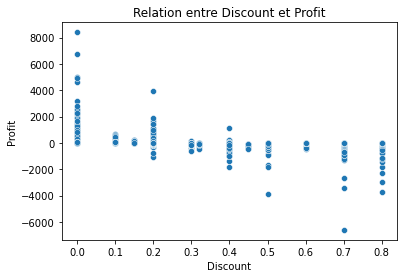

In [5]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Discount", y="Profit")
plt.title("Relation entre Discount et Profit")
plt.show()

In [6]:
df["Discount"].corr(df["Profit"])

-0.21948745637176806

La corrélation entre Discount et Profit est de -0.219, indiquant une relation négative faible.
Cela suggère qu’une augmentation des remises tend à réduire la rentabilité, mais que d’autres facteurs influencent également le profit.

## Analyse par catégorie

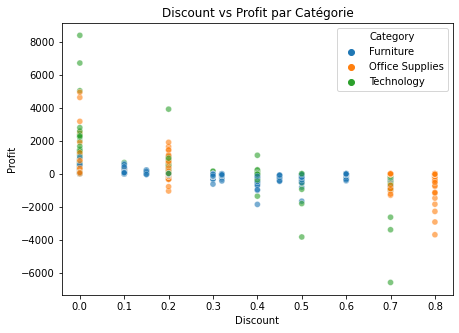

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", alpha=0.6)
plt.title("Discount vs Profit par Catégorie")
plt.show()

In [8]:
df.groupby("Category")[["Discount","Profit"]].corr()

Discount    Profit
Category                                    
Furniture       Discount  1.000000 -0.483769
                Profit   -0.483769  1.000000
Office Supplies Discount  1.000000 -0.208787
                Profit   -0.208787  1.000000
Technology      Discount  1.000000 -0.268853
                Profit   -0.268853  1.000000

L’analyse segmentée révèle que la catégorie Furniture est la plus sensible aux remises (corrélation -0.48).
Cette catégorie pourrait présenter des coûts logistiques élevés ou des marges structurellement plus faibles, rendant les promotions plus risquées.
Cela suggère qu’une politique promotionnelle agressive sur cette catégorie détruit significativement la marge.
En revanche, Technology et Office Supplies semblent mieux absorber les remises.

### Profit par région

In [9]:
df.groupby("Region")["Profit"].mean().sort_values()

Region
Central    17.092709
South      28.857673
East       32.135808
West       33.849032
Name: Profit, dtype: float64

### Sales moyen par région

In [10]:
df.groupby("Region")["Sales"].mean().sort_values()

Region
Central    215.772661
West       226.493233
East       238.336110
South      241.803645
Name: Sales, dtype: float64

In [11]:
df["Margin"] = df["Profit"] / df["Sales"]

df.groupby("Region")["Margin"].mean().sort_values()

Region
Central   -0.104073
South      0.163519
East       0.167227
West       0.219487
Name: Margin, dtype: float64

## Analyser le mix produit par région

In [12]:
pd.crosstab(df["Region"], df["Category"])

Category,Furniture,Office Supplies,Technology
Region,,,
Central,481,1422,420
East,601,1712,535
South,332,995,293
West,707,1897,599


## Volume total par catégorie et région

In [13]:
df.groupby(["Region","Category"])["Sales"].sum()

Region   Category       
Central  Furniture          163797.1638
         Office Supplies    167026.4150
         Technology         170416.3120
East     Furniture          208291.2040
         Office Supplies    205516.0550
         Technology         264973.9810
South    Furniture          117298.6840
         Office Supplies    125651.3130
         Technology         148771.9080
West     Furniture          252612.7435
         Office Supplies    220853.2490
         Technology         251991.8320
Name: Sales, dtype: float64

## Volume total par catégorie et région

In [14]:
df.groupby("Region")["Discount"].mean().sort_values()

Region
West       0.109335
East       0.145365
South      0.147253
Central    0.240353
Name: Discount, dtype: float64

La région Central présente une remise moyenne de 24 %, nettement supérieure aux autres régions (~14 %). Cette politique promotionnelle agressive semble expliquer sa faible marge et sa rentabilité inférieure.

In [15]:
df.groupby(["Region","Category"])["Discount"].mean()

Region   Category       
Central  Furniture          0.297380
         Office Supplies    0.252743
         Technology         0.133095
East     Furniture          0.154077
         Office Supplies    0.142932
         Technology         0.143364
South    Furniture          0.121536
         Office Supplies    0.167437
         Technology         0.107850
West     Furniture          0.131400
         Office Supplies    0.093358
         Technology         0.133890
Name: Discount, dtype: float64

L’analyse montre que la région Central applique en moyenne 29.7 % de remise sur la catégorie Furniture, contre environ 13 % dans les autres régions.
Or, Furniture présente la plus forte sensibilité négative aux remises (corrélation -0.48).
Cette combinaison explique la faible rentabilité structurelle de la région Central.

## 3 - Matrice de corrélation

### Profit par Région

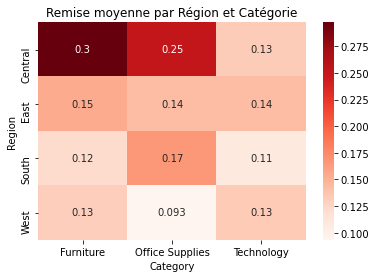

In [16]:
pivot = df.groupby(["Region","Category"])["Discount"].mean().unstack()

sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Remise moyenne par Région et Catégorie")
plt.show()

## Recommandations stratégiques

1 - Réduire les remises sur Furniture
- Tester une réduction progressive (ex : 30 % → 20 %)
- Mettre en place un seuil maximum de discount
- Surveiller l’impact sur le volume

2 - Revoir la stratégie de pricing
- Vérifier les marges unitaires
- Identifier les produits Furniture structurellement non rentables
- Ajuster les prix plutôt que compenser par remise

## Discount ↔ Quantity

In [17]:
df["Discount"].corr(df["Quantity"])

0.008622970271156561

In [18]:
df[df["Region"]=="Central"]["Discount"].corr(df[df["Region"]=="Central"]["Quantity"])

0.014794428802290021

## Heatmap des corrélations globales

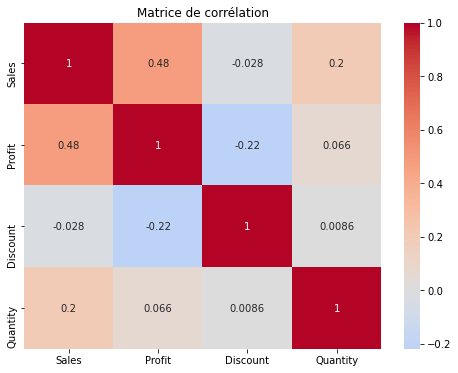

In [19]:
plt.figure(figsize=(8,6))
corr_matrix = df[["Sales","Profit","Discount","Quantity"]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

## 4 - Conclusion & recommandations

1. Relations principales identifiées
- Sales et Profit sont modérément corrélés (r = 0.48)
- Discount est négativement corrélé au Profit (r = -0.22)
- Discount n’a quasiment aucun impact sur Quantity (r ≈ 0.01)
Les remises réduisent la rentabilité sans augmenter significativement le volume.

2. Analyse régionale
- La région Central présente la marge la plus faible.
- Elle applique la remise moyenne la plus élevée (≈ 24 %).
- Sur Furniture, la remise atteint près de 30 %.
Politique promotionnelle particulièrement agressive.

3. Analyse par catégorie
- Furniture est la catégorie la plus sensible aux remises (r = -0.48).
- La combinaison “Furniture + Central + forte remise” explique la faible rentabilité régionale.

### Insights Business
- Les remises ne génèrent pas d’augmentation de volume.
- Elles détruisent la rentabilité, surtout sur Furniture.
- La région Central applique des remises excessives sans bénéfice volume.
- La performance commerciale dépend davantage du niveau de ventes que du volume unitaire.

### Recommandations
1️⃣ Réduire les remises sur Furniture en région Central

2️⃣ Introduire un plafond de remise

3️⃣ Tester une stratégie différenciée par catégorie

4️⃣ Mettre en place un suivi mensuel de la marge par région